In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime 

In [12]:
customer = pd.read_csv("Customer.csv")

In [13]:
prod = pd.read_csv("prod_cat_info.csv")

In [14]:
transactions = pd.read_csv("Transactions.csv")

In [15]:
customer

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0
3,270181,10-01-1970,F,2.0
4,268073,11-01-1970,M,1.0
...,...,...,...,...
5642,274474,19-12-1992,M,2.0
5643,267666,24-12-1992,M,6.0
5644,270476,25-12-1992,F,3.0
5645,269626,27-12-1992,F,5.0


In [16]:
prod

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women
5,2,Footwear,4,Kids
6,3,Electronics,4,Mobiles
7,3,Electronics,5,Computers
8,3,Electronics,8,Personal Appliances
9,3,Electronics,9,Cameras


In [17]:
transactions

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
...,...,...,...,...,...,...,...,...,...,...
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop


In [69]:
customer.rename(columns={'customer_Id' : 'cust_id'}, inplace=True) # renaming columns
cust_trans = pd.merge(transactions, customer, on= "cust_id", how= "inner") # merging tables transactions over table customer

In [24]:
cust_trans

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,08-06-1981,M,3.0
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop,21-02-1972,M,7.0
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop,27-04-1984,M,9.0
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR,20-06-1976,M,8.0
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,22-05-1970,M,2.0


In [70]:
prod.rename(columns={'prod_sub_cat_code':'prod_subcat_code'}, inplace=True) # renaming columns
customer_final= pd.merge (cust_trans,  prod, on=['prod_cat_code', 'prod_subcat_code'], how = "left") #Merging tables cust_trans with prod to merge all 3 tables

In [28]:
customer_final

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,Women
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,Computers
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0,Books,DIY
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,08-06-1981,M,3.0,Home and kitchen,Bath
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0,Books,DIY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop,21-02-1972,M,7.0,Books,Academic
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop,27-04-1984,M,9.0,Clothing,Mens
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR,20-06-1976,M,8.0,Home and kitchen,Furnishing
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,22-05-1970,M,2.0,Books,Children


In [71]:
customer_final.dtypes # checking data types

transaction_id        int64
cust_id               int64
tran_date            object
prod_subcat_code      int64
prod_cat_code         int64
Qty                   int64
Rate                  int64
Tax                 float64
total_amt           float64
Store_type           object
DOB                  object
Gender               object
city_code           float64
prod_cat             object
prod_subcat          object
dtype: object

In [31]:
customer_final.head(10)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,Women
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,Computers
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0,Books,DIY
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop,08-06-1981,M,3.0,Home and kitchen,Bath
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0,Books,DIY
5,97439039119,272357,23-02-2014,8,3,-2,-824,173.040,-1821.040,TeleShop,09-10-1982,F,6.0,Electronics,Personal Appliances
6,45649838090,273667,22-02-2014,11,6,-1,-1450,152.250,-1602.250,e-Shop,29-05-1981,M,9.0,Home and kitchen,Bath
7,22643667930,271489,22-02-2014,12,6,-1,-1225,128.625,-1353.625,TeleShop,21-04-1971,M,9.0,Home and kitchen,Tools
8,79792372943,275108,22-02-2014,3,1,-3,-908,286.020,-3010.020,MBR,04-11-1971,F,8.0,Clothing,Kids
9,50076728598,269014,21-02-2014,8,3,-4,-581,244.020,-2568.020,e-Shop,27-11-1979,F,3.0,Electronics,Personal Appliances


In [32]:
customer_final.tail(10)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_subcat
23043,49882891062,271982,25-01-2011,10,5,4,1330,558.600,5878.600,e-Shop,10-08-1976,M,8.0,Books,Non-Fiction
23044,14787475597,273982,25-01-2011,4,3,5,969,508.725,5353.725,e-Shop,12-10-1991,M,4.0,Electronics,Mobiles
23045,50691119572,273031,25-01-2011,6,5,1,1148,120.540,1268.540,TeleShop,17-01-1980,F,8.0,Books,DIY
23046,40893803228,272049,25-01-2011,11,6,3,1077,339.255,3570.255,e-Shop,28-06-1975,F,6.0,Home and kitchen,Bath
23047,30856003613,266866,25-01-2011,4,2,2,444,93.240,981.240,TeleShop,18-04-1974,M,4.0,Footwear,Kids
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop,21-02-1972,M,7.0,Books,Academic
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop,27-04-1984,M,9.0,Clothing,Mens
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR,20-06-1976,M,8.0,Home and kitchen,Furnishing
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop,22-05-1970,M,2.0,Books,Children
23052,77960931771,271961,25-01-2011,11,5,1,447,46.935,493.935,TeleShop,15-01-1982,M,1.0,Books,Children


In [33]:
customer_final.describe

<bound method NDFrame.describe of        transaction_id  cust_id   tran_date  prod_subcat_code  prod_cat_code  \
0         80712190438   270351  28-02-2014                 1              1   
1         29258453508   270384  27-02-2014                 5              3   
2         51750724947   273420  24-02-2014                 6              5   
3         93274880719   271509  24-02-2014                11              6   
4         51750724947   273420  23-02-2014                 6              5   
...               ...      ...         ...               ...            ...   
23048     94340757522   274550  25-01-2011                12              5   
23049     89780862956   270022  25-01-2011                 4              1   
23050     85115299378   271020  25-01-2011                 2              6   
23051     72870271171   270911  25-01-2011                11              5   
23052     77960931771   271961  25-01-2011                11              5   

       Qty  Rate 

In [72]:
customer_final['Gender'].value_counts() # calculating number of males and females in the dataset

Gender
M    11811
F    11233
Name: count, dtype: int64

In [73]:
customer_final['prod_cat'].value_counts() #calculating total number of products each category holds

prod_cat
Books               6069
Electronics         4898
Home and kitchen    4129
Footwear            2999
Clothing            2960
Bags                1998
Name: count, dtype: int64

In [74]:
customer_final['Store_type'].value_counts() # calculating total number of each of the store type

Store_type
e-Shop            9311
MBR               4661
Flagship store    4577
TeleShop          4504
Name: count, dtype: int64

<Axes: >

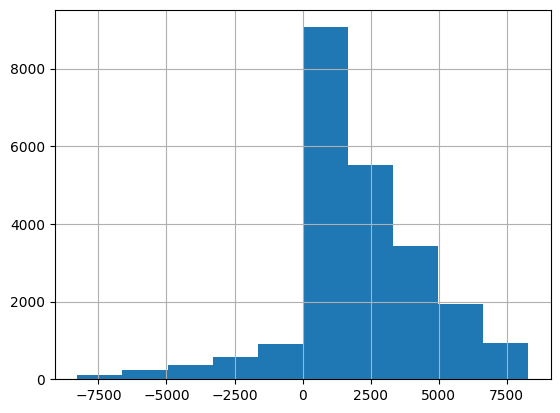

In [76]:
customer_final['total_amt'].hist() # creating histogram of continous columns

<Axes: xlabel='city_code'>

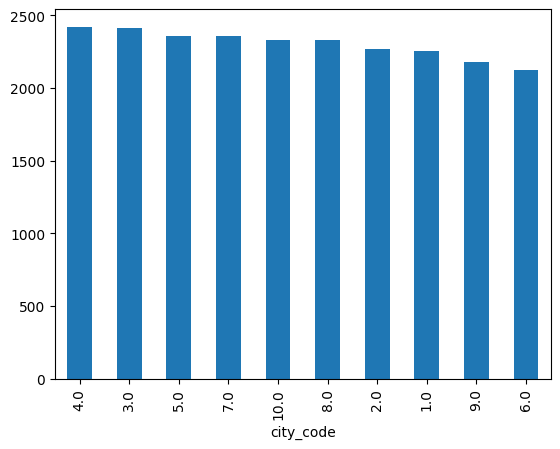

In [77]:
customer_final['city_code'].value_counts().plot(kind='bar') # creating histogram of categorical columns

In [113]:
#Using merged dataset
# correcting the format
customer_final['tran_date'] = pd.to_datetime( customer_final['tran_date'], errors='coerce', dayfirst=True)
#verifying
customer_final['tran_date'].head

#a) Time period of available transaction data
customer_final['tran_date'].min(),customer_final['tran_date'].max()

#b) Count of transactions with negative total amount
(customer_final['total_amt']<0).sum()

np.int64(2177)

<bound method NDFrame.head of 0       2014-02-28
1       2014-02-27
2       2014-02-24
3       2014-02-24
4       2014-02-23
           ...    
23048   2011-01-25
23049   2011-01-25
23050   2011-01-25
23051   2011-01-25
23052   2011-01-25
Name: tran_date, Length: 23053, dtype: datetime64[ns]>

In [108]:
#Product categories more popular among male vs female
gp= customer_final.groupby(['Gender', 'prod_cat'])['Qty'].sum().reset_index()
gp.sort_values(['Gender','Qty'],ascending= False)

,Gender,prod_cat,Qty
7,M,Books,7587
9,M,Electronics,6476
11,M,Home and kitchen,5041
8,M,Clothing,3748
10,M,Footwear,3555
6,M,Bags,2346
1,F,Books,7070
3,F,Electronics,5832
5,F,Home and kitchen,4895
4,F,Footwear,3716


In [103]:
#City code with maximum customers
#unique customers per city.
city_counts= customer_final.groupby('city_code')['cust_id'].nunique()
city_counts

city_code
1.0     535
2.0     546
3.0     576
4.0     569
5.0     570
6.0     516
7.0     563
8.0     551
9.0     532
10.0    546
Name: cust_id, dtype: int64

In [104]:
# city with maximum customers:
max_city= city_counts.idxmax()
max_city

np.float64(3.0)

In [105]:
# Percentage:
(city_counts.max() / city_counts.sum()) * 100

np.float64(10.465116279069768)

In [65]:
#Store type selling maximum products(by value)
customer_final.groupby('Store_type')['total_amt'].sum().sort_values(ascending=False)

Store_type
e-Shop            1.982482e+07
Flagship store    9.715688e+06
MBR               9.674486e+06
TeleShop          9.364781e+06
Name: total_amt, dtype: float64

In [66]:
#Store type selling maximum products (by quantity)
customer_final.groupby('Store_type')['Qty'].sum().sort_values(ascending=False)

Store_type
e-Shop            22763
MBR               11194
Flagship store    11133
TeleShop          10984
Name: Qty, dtype: int64

In [85]:
#Total amount from 'Electronics' & 'Clothing' in Flagship Stores
customer_final[
    (customer_final['Store_type'] == 'Flagship store') &
    (customer_final['prod_cat'].isin(['Electronics', 'Clothing']))
]['total_amt'].sum()

np.float64(3409559.27)

In [86]:
#Total amount from 'Male' customers under Electronics
customer_final[
    (customer_final['Gender'] == 'M') &
    (customer_final['prod_cat'] == 'Electronics')
]['total_amt'].sum()

np.float64(5703109.424999999)

In [88]:
# Number of customers with >10 unique transactions
#First remove negative transactions:
filtered = customer_final[customer_final['total_amt'] >=0 ]
#counting unique transaction IDs
t_count = filtered.groupby('cust_id')['transaction_id'].nunique()
t_count[t_count > 10].count()

np.int64(6)

In [102]:
# Customers aged 25–35 years
#processing
#computing age
customer_final['DOB'] = pd.to_datetime(customer_final['DOB'], errors = 'coerce', dayfirst = True)
customer_final['Age'] = (pd.Timestamp("2014-12-31") - customer_final['DOB']).dt.days // 365
#selecting age group (25-35)
age_25_35 = customer_final[(customer_final['Age'] >= 25) & (customer_final['Age'] <= 35)]

# a) total amount spent on electronics & books (age group 25-35) (combined amount)
age_25_35[ age_25_35['prod_cat'].isin(['Electronics', 'Books'])]['total_amt'].sum()
#(category wise)
age_25_35[age_25_35['prod_cat'].isin(['Electronics','Books'])].groupby('prod_cat')['total_amt'].sum()

# b) total spent between Jan 1,2014 and March 1,2014 (age 25-35)
#filtering by date range
jan_mar = age_25_35[(age_25_35['tran_date'] >= '2014-01-01') & (age_25_35['tran_date'] <= '2014-03-01')]
# sum of the amonut
jan_mar['total_amt'].sum()

np.float64(0.0)